# 🍊 내일의 제주 — 제주 특산물 가격 예측

## 팀 정보

| 항목 | 내용 |
|------|------|
| **팀명** | 내일의 제주 |
| **대회** | DACON 제주 특산물 가격 예측 AI 경진대회 |
| **DACON** | https://dacon.io/competitions/official/236176/overview/description |
| **GitHub** | https://github.com/chul3224/Tomorrow-Jeju |
| **진행 기간** | 2026-03-09 ~ 2026-03-18 |
| **발표일** | 2026-03-18 |

## 팀원 및 담당 파트

| 이름 | 역할 | 담당 파트 |
|------|------|----------|
| 박효준 (조장) | 데이터 탐색 및 시각화 | EDA |
| 김대원 | 피처 설계 및 앙상블 구조 | 피처 엔지니어링 |
| 신우철 | 모델 버전 관리 및 최종 통합 | 모델링 |

## 최종 모델 구성

| 항목 | 내용 |
|------|------|
| **모델** | LightGBM + XGBoost + CatBoost (VotingRegressor) + DNN 앙상블 |
| **그룹 전략** | TG / RD+CR / BC+CB — 3그룹 분리 학습 |
| **핵심 피처** | 달력 9개 + 명절 거리(dist_seollal, dist_chuseok) + 범주형 3개 |
| **타겟 변환** | TG → sqrt 변환 / 나머지 → log1p 변환 |
| **검증 방식** | 시즌 Hold-Out (2022-03) + 5-Fold 재학습 |
| **학습 기간** | 2019-01-01 ~ 2023-03-03 (59,397행) |
| **예측 기간** | 2023-03-04 ~ 2023-03-31 |

## 검증 결과 및 최종 점수

| 구분 | MAE |
|------|-----|
| Hold-Out 전체 MAE (2022-03) | **493.17** 원/kg |
| 예상 Public Score | **≈ 621** 원 |
| 팀 최고 Public Score (v1.0.1) | **658.6** 원 |

> 출력 파일: `results/submission_v13.1.csv`

---
## 1. 환경 설정 및 데이터 로드

In [1]:
import os
import pandas as pd
import numpy as np
import datetime
import holidays
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

try:
    from korean_font import set_korean_font
    set_korean_font()
except:
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import VotingRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

DATA_PATH = '../data/'
train = pd.read_csv(DATA_PATH + 'train.csv', encoding='utf-8-sig')
test  = pd.read_csv(DATA_PATH + 'test.csv',  encoding='utf-8-sig')
sub   = pd.read_csv(DATA_PATH + 'sample_submission.csv', encoding='utf-8-sig')

train['timestamp'] = pd.to_datetime(train['timestamp'])
test['timestamp']  = pd.to_datetime(test['timestamp'])

print(f'Train: {train.shape}, Test: {test.shape}')

Train: (59397, 7), Test: (1092, 5)


---
## 2. EDA — 시계열 및 이상치 확인

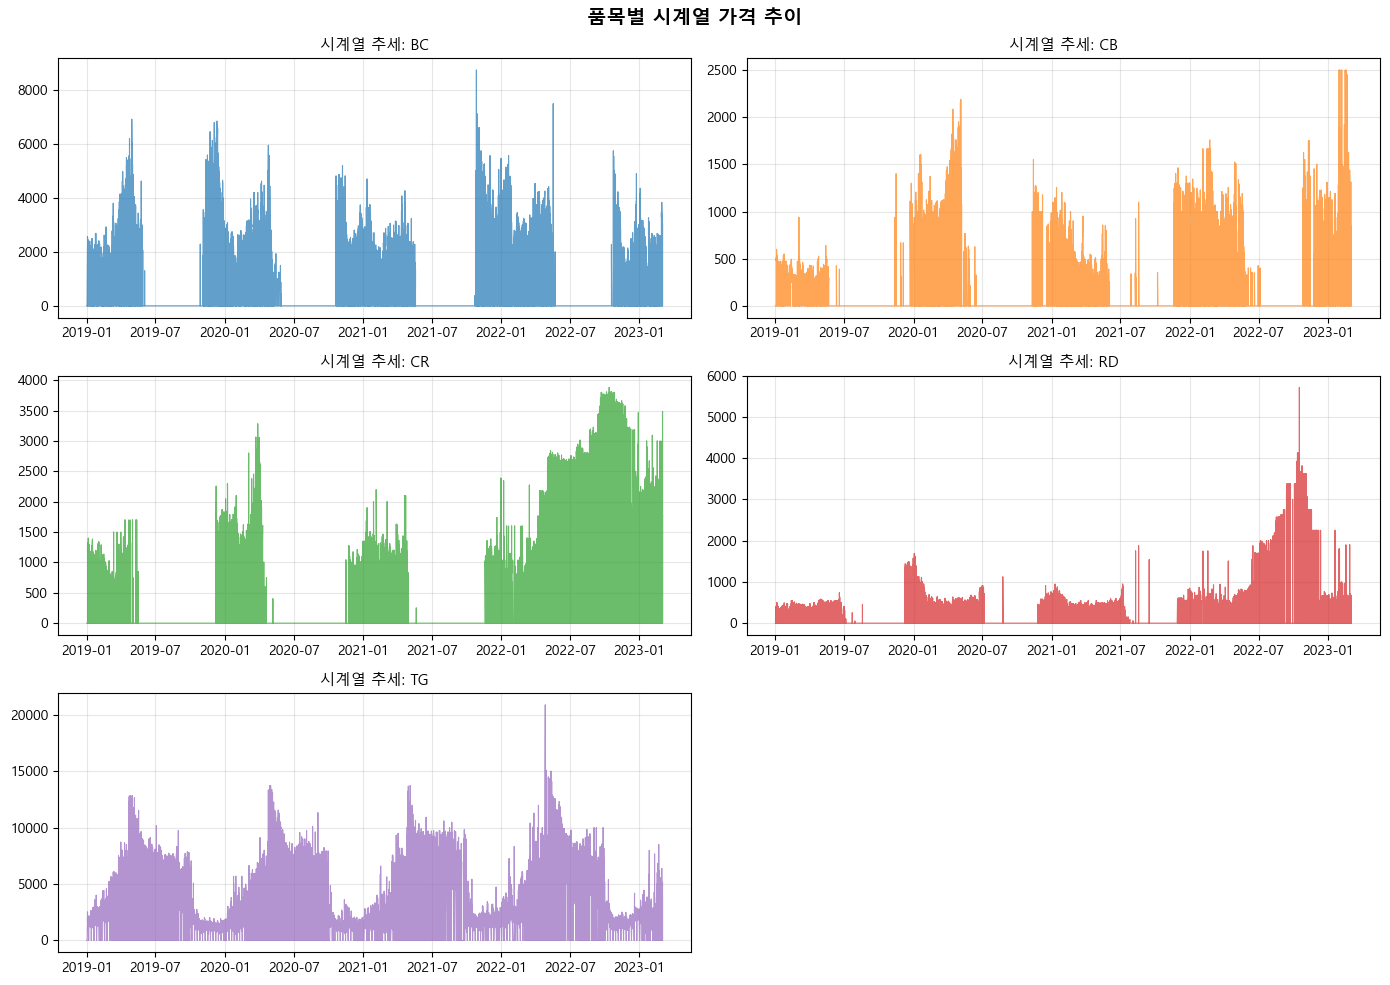

In [2]:
# 품목별 시계열 추이
items = sorted(train['item'].unique())
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

for i, item in enumerate(items):
    d = train[train['item'] == item].sort_values('timestamp')
    axes[i].plot(d['timestamp'], d['price(원/kg)'], lw=0.8, alpha=0.7, color=f'C{i}')
    axes[i].set_title(f'시계열 추세: {item}', fontsize=11)
    axes[i].grid(True, alpha=0.3)

axes[-1].set_visible(False)
plt.suptitle('품목별 시계열 가격 추이', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

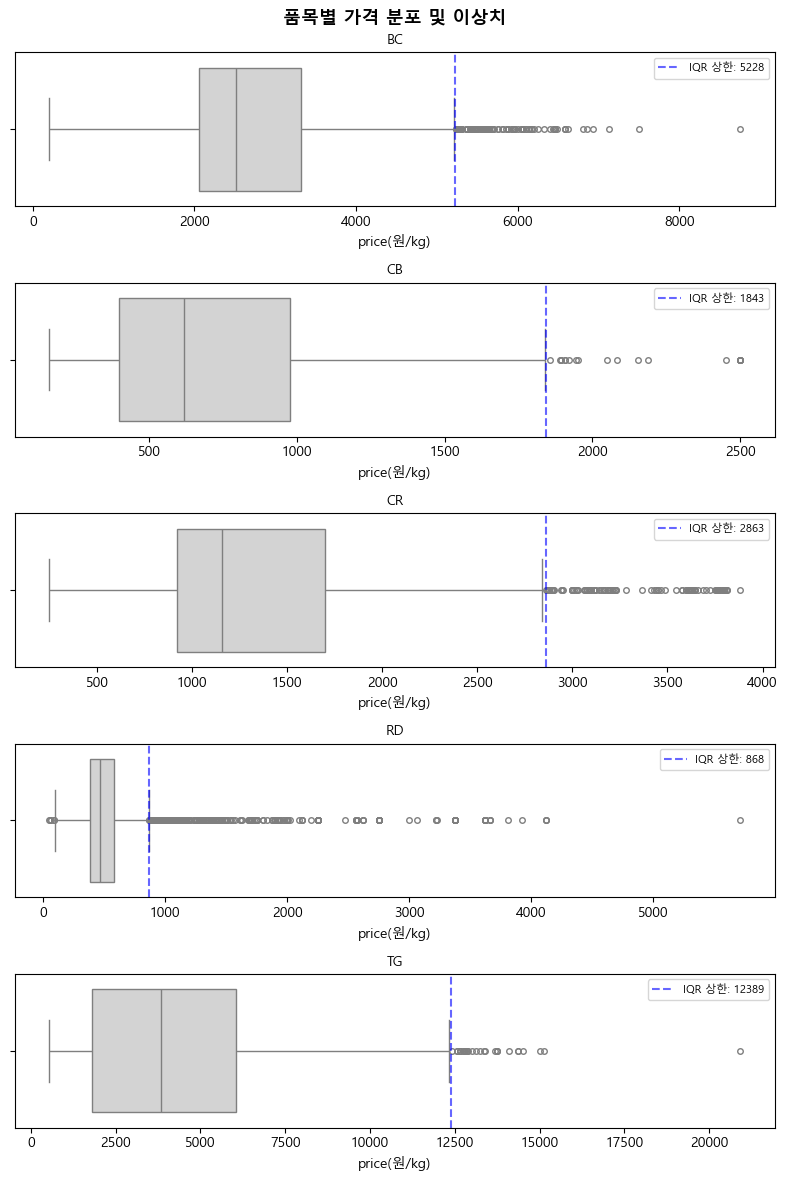

In [3]:
# Boxplot + IQR 이상치 확인
fig, axes = plt.subplots(5, 1, figsize=(8, 12))
for i, item in enumerate(items):
    df_i = train[(train['item'] == item) & (train['price(원/kg)'] > 0)]
    Q1, Q3 = df_i['price(원/kg)'].quantile([0.25, 0.75])
    upper = Q3 + 1.5 * (Q3 - Q1)
    sns.boxplot(data=df_i, x='price(원/kg)', ax=axes[i], color='lightgray', fliersize=4)
    axes[i].axvline(upper, color='blue', linestyle='--', alpha=0.6, label=f'IQR 상한: {upper:.0f}')
    axes[i].set_title(f'{item}', fontsize=10)
    axes[i].legend(fontsize=8)
plt.suptitle('품목별 가격 분포 및 이상치', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

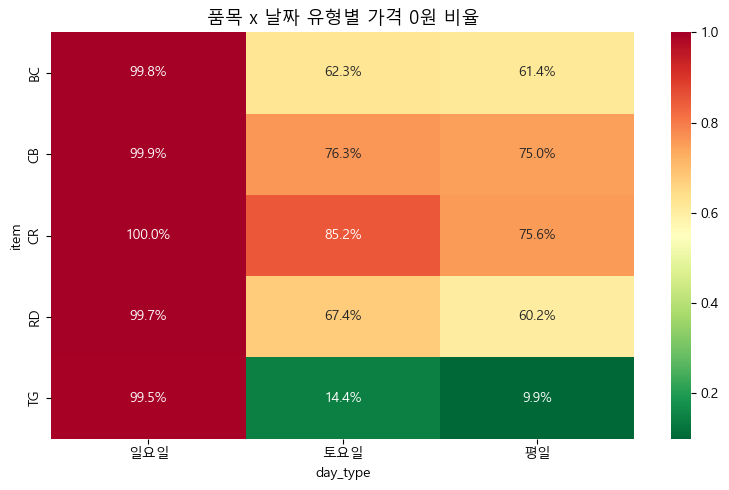

In [4]:
# 요일별 0원 비율 (일요일 휴장 확인)
train['dow'] = train['timestamp'].dt.dayofweek
train['is_zero'] = (train['price(원/kg)'] == 0).astype(int)
train['day_type'] = train['dow'].map({0:'평일',1:'평일',2:'평일',3:'평일',4:'평일',5:'토요일',6:'일요일'})

pivot = train.groupby(['item','day_type'])['is_zero'].mean().unstack()
plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.1%', cmap='RdYlGn_r')
plt.title('품목 x 날짜 유형별 가격 0원 비율', fontsize=13)
plt.tight_layout()
plt.show()

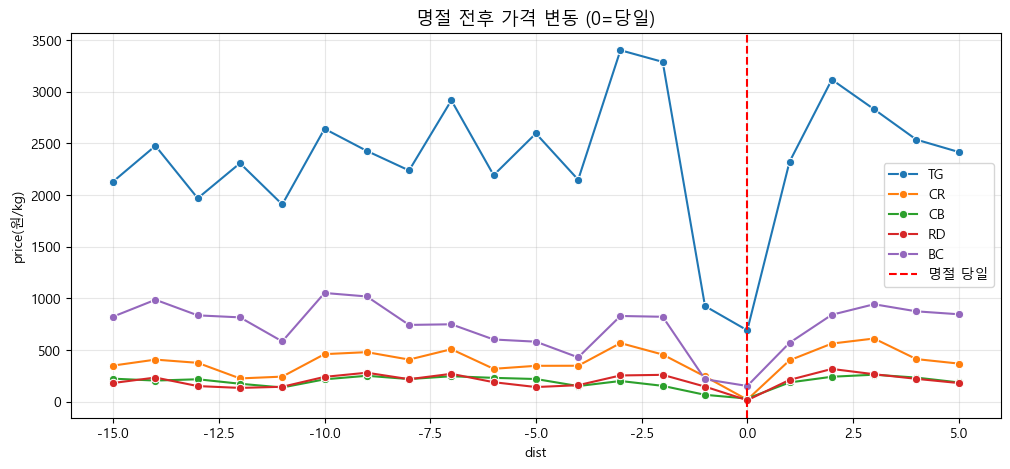

In [5]:
# 명절 전후 가격 변동
def get_trad_holidays(years):
    kr_h = holidays.KR(years=years)
    return sorted([d for d, n in kr_h.items()
                   if any(k in n for k in ['설날','추석','Lunar','Chuseok'])])

holiday_dates = get_trad_holidays(range(2019, 2024))

def calc_dist(date):
    diffs = [(pd.Timestamp(h).date() - date.date()).days for h in holiday_dates]
    return min(diffs, key=abs)

train_h = train.copy()
train_h['dist'] = train_h['timestamp'].apply(calc_dist)

mask = (train_h['dist'] >= -15) & (train_h['dist'] <= 5)
plt.figure(figsize=(12, 5))
sns.lineplot(x='dist', y='price(원/kg)', hue='item',
             data=train_h[mask], marker='o', errorbar=None)
plt.axvline(0, color='red', linestyle='--', label='명절 당일')
plt.title('명절 전후 가격 변동 (0=당일)', fontsize=13)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

---
## 3. 전처리 및 피처 엔지니어링

### GeminiCLI13 대비 변경
- ❌ **EMA_7 / EMA_30 제거** — 테스트 기간 freeze 문제 (v4.1.0 실패 경험)
- ✅ **year_month 추가** — v1.0.1 Public 658.6 핵심 피처

In [6]:
# 이상치 처리 (1위 전략, v1.0.1 동일)
outlier_thresholds = {'TG': 20000, 'RD': 5000, 'BC': 8000, 'CB': 2300}
for item, thr in outlier_thresholds.items():
    mask = (train['item'] == item) & (train['price(원/kg)'] > thr)
    if mask.any():
        mean_val = train[(train['item'] == item) & (train['price(원/kg)'] > 0)]['price(원/kg)'].mean()
        train.loc[mask, 'price(원/kg)'] = mean_val
        print(f'{item}: {mask.sum()}개 이상치 → 평균({mean_val:.0f})으로 대체')

print('이상치 처리 완료')

TG: 1개 이상치 → 평균(4145)으로 대체
RD: 1개 이상치 → 평균(564)으로 대체
BC: 1개 이상치 → 평균(2757)으로 대체
CB: 7개 이상치 → 평균(715)으로 대체
이상치 처리 완료


In [7]:
# 명절 날짜
SEOLLAL = [pd.Timestamp(d) for d in ['2019-02-05','2020-01-25','2021-02-12','2022-02-01','2023-01-22']]
CHUSEOK = [pd.Timestamp(d) for d in ['2019-09-13','2020-10-01','2021-09-21','2022-09-10','2023-09-29']]

def preprocess(df):
    df = df.copy()
    df['year']     = df['timestamp'].dt.year
    df['month']    = df['timestamp'].dt.month
    df['day']      = df['timestamp'].dt.day
    df['dow']      = df['timestamp'].dt.dayofweek

    # week_num: 2019-01-01 기준 절대 주차
    df['week_num'] = (df['timestamp'] - pd.to_datetime('2019-01-01')).dt.days // 7

    # year_month: 누적 개월 수 LabelEncoding (v1.0.1 핵심)
    # → 트리·DNN 모두 시간 흐름을 인식
    df['year_month_str'] = df['timestamp'].map(lambda x: f'{x.year}-{x.month}')

    # 명절 거리 피처 (v5.0.0 + kim-dw 동일)
    df['dist_seollal'] = df['timestamp'].map(
        lambda d: min(min(abs((d - h).days) for h in SEOLLAL), 30)
    )
    df['dist_chuseok'] = df['timestamp'].map(
        lambda d: min(min(abs((d - h).days) for h in CHUSEOK), 30)
    )

    # holiday
    kr_h = holidays.KR()
    df['holiday'] = df['timestamp'].apply(lambda x: 1 if x in kr_h else 0)

    return df

train_p = preprocess(train)
test_p  = preprocess(test)

# year_month LabelEncoding — train+test 합쳐서 fit (인코딩 일관성)
le_ym = LabelEncoder()
le_ym.fit(pd.concat([train_p, test_p])['year_month_str'])
train_p['year_month'] = le_ym.transform(train_p['year_month_str'])
test_p['year_month']  = le_ym.transform(test_p['year_month_str'])

# TG 공휴일 보정: 공휴일이지만 실제 거래된 날은 holiday=0으로 수정
no_holiday = train_p[(train_p['holiday'] == 1) & (train_p['price(원/kg)'] > 0)]['timestamp'].unique()
train_p.loc[train_p['timestamp'].isin(no_holiday), 'holiday'] = 0
test_p.loc[test_p['timestamp'].isin(no_holiday), 'holiday'] = 0

print('전처리 완료')
print(f'피처 목록 확인: year_month={train_p["year_month"].nunique()}개 고유값')

전처리 완료
피처 목록 확인: year_month=51개 고유값


In [8]:
# 범주형 LabelEncoding (item, corporation, location)
le_cols = ['item', 'corporation', 'location']
le_dict = {col: LabelEncoder().fit(train_p[col]) for col in le_cols}
for col in le_cols:
    train_p[col] = le_dict[col].transform(train_p[col])
    test_p[col]  = le_dict[col].transform(test_p[col])

item_codes = {name: le_dict['item'].transform([name])[0] for name in le_dict['item'].classes_}
print('item 코드:', item_codes)

# 타겟 변환: TG=sqrt, 비TG=log1p
train_p['target'] = np.where(
    train_p['item'] == item_codes['TG'],
    np.sqrt(train_p['price(원/kg)']),
    np.log1p(train_p['price(원/kg)'])
)

# 피처 정의 (EMA 제거, year_month 추가)
FEATS = [
    'item', 'corporation', 'location',
    'year', 'month', 'day', 'dow',
    'week_num', 'year_month',       # year_month 추가 (v1.0.1 핵심)
    'holiday',
    'dist_seollal', 'dist_chuseok'  # 명절 거리
    # ema_7, ema_30 제거 — freeze 문제
]

print(f'\n피처 수: {len(FEATS)}개')
print(f'피처: {FEATS}')

item 코드: {'BC': np.int64(0), 'CB': np.int64(1), 'CR': np.int64(2), 'RD': np.int64(3), 'TG': np.int64(4)}

피처 수: 12개
피처: ['item', 'corporation', 'location', 'year', 'month', 'day', 'dow', 'week_num', 'year_month', 'holiday', 'dist_seollal', 'dist_chuseok']


In [9]:
# 스케일링
scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(train_p[FEATS]), columns=FEATS)
X_test_sc  = pd.DataFrame(scaler.transform(test_p[FEATS]),  columns=FEATS)
print('스케일링 완료')

스케일링 완료


---
## 4. Hold-Out 검증 (2022-03)

> **추가된 섹션** — GeminiCLI13에는 없던 검증 단계  
> KFold는 미래 데이터가 훈련에 섞여 MAE가 낙관적 → 시즌 Hold-Out으로 실제 성능 확인

In [10]:
# 2022-03을 검증, 나머지로 학습
val_mask = (train['timestamp'] >= '2022-03-01') & (train['timestamp'] < '2022-04-01')

tr_df  = train_p[~val_mask.values].copy().reset_index(drop=True)
val_df = train_p[val_mask.values].copy().reset_index(drop=True)

X_tr_sc  = pd.DataFrame(scaler.transform(tr_df[FEATS]),  columns=FEATS)
X_val_sc = pd.DataFrame(scaler.transform(val_df[FEATS]), columns=FEATS)

print(f'Hold-Out 학습: {len(tr_df):,}행 / 검증(2022-03): {len(val_df):,}행')

# 그룹 마스크 (Hold-Out용)
m_tg_h    = tr_df['item'] == item_codes['TG']
m_rdcr_h  = tr_df['item'].isin([item_codes['RD'], item_codes['CR']])
m_bccb_h  = tr_df['item'].isin([item_codes['BC'], item_codes['CB']])

vm_tg    = val_df['item'] == item_codes['TG']
vm_rdcr  = val_df['item'].isin([item_codes['RD'], item_codes['CR']])
vm_bccb  = val_df['item'].isin([item_codes['BC'], item_codes['CB']])

def train_tree_group(X_tr, y_tr, X_pred):
    tree = VotingRegressor([
        ('lgbm', LGBMRegressor(n_estimators=1000, learning_rate=0.01, random_state=SEED, verbose=-1)),
        ('xgb',  XGBRegressor(n_estimators=1000, learning_rate=0.01, random_state=SEED, verbosity=0)),
        ('cat',  CatBoostRegressor(iterations=1000, learning_rate=0.01, random_state=SEED, verbose=0))
    ])
    tree.fit(X_tr, y_tr)
    return tree.predict(X_pred)

def build_dnn(input_dim):
    l2 = regularizers.l2(1e-4)
    model = keras.Sequential([
        layers.Dense(256, kernel_regularizer=l2, input_shape=(input_dim,)),
        layers.BatchNormalization(), layers.Activation('relu'), layers.Dropout(0.3),
        layers.Dense(128, kernel_regularizer=l2),
        layers.BatchNormalization(), layers.Activation('relu'), layers.Dropout(0.2),
        layers.Dense(64, kernel_regularizer=l2),
        layers.BatchNormalization(), layers.Activation('relu'),
        layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mae')
    return model

# Hold-Out 검증 (TG 그룹)
print('Hold-Out 검증 중 (TG)...')
tree_pred_tg = train_tree_group(X_tr_sc[m_tg_h], tr_df['target'][m_tg_h], X_val_sc[vm_tg])
dnn_tg = build_dnn(len(FEATS))
dnn_tg.fit(X_tr_sc[m_tg_h], tr_df['target'][m_tg_h],
           validation_split=0.1, epochs=100, batch_size=128,
           callbacks=[callbacks.EarlyStopping(patience=15, restore_best_weights=True)], verbose=0)
dnn_pred_tg = dnn_tg.predict(X_val_sc[vm_tg], verbose=0).flatten()
val_pred_tg = tree_pred_tg * 0.6 + dnn_pred_tg * 0.4

# Hold-Out 검증 (RD+CR 그룹)
print('Hold-Out 검증 중 (RD+CR)...')
tree_pred_rc = train_tree_group(X_tr_sc[m_rdcr_h], tr_df['target'][m_rdcr_h], X_val_sc[vm_rdcr])
dnn_rc = build_dnn(len(FEATS))
dnn_rc.fit(X_tr_sc[m_rdcr_h], tr_df['target'][m_rdcr_h],
           validation_split=0.1, epochs=100, batch_size=128,
           callbacks=[callbacks.EarlyStopping(patience=15, restore_best_weights=True)], verbose=0)
dnn_pred_rc = dnn_rc.predict(X_val_sc[vm_rdcr], verbose=0).flatten()
val_pred_rc = tree_pred_rc * 0.6 + dnn_pred_rc * 0.4

# Hold-Out 검증 (BC+CB 그룹)
print('Hold-Out 검증 중 (BC+CB)...')
tree_pred_bc = train_tree_group(X_tr_sc[m_bccb_h], tr_df['target'][m_bccb_h], X_val_sc[vm_bccb])
dnn_bc = build_dnn(len(FEATS))
dnn_bc.fit(X_tr_sc[m_bccb_h], tr_df['target'][m_bccb_h],
           validation_split=0.1, epochs=100, batch_size=128,
           callbacks=[callbacks.EarlyStopping(patience=15, restore_best_weights=True)], verbose=0)
dnn_pred_bc = dnn_bc.predict(X_val_sc[vm_bccb], verbose=0).flatten()
val_pred_bc = tree_pred_bc * 0.6 + dnn_pred_bc * 0.4

# 역변환 후 MAE 계산
def inverse_transform(preds, item_code, is_tg=True):
    return np.where(is_tg, np.power(np.clip(preds, 0, None), 2), np.expm1(preds))

y_val_tg_orig = val_df[vm_tg]['price(원/kg)'].values
y_val_rc_orig = val_df[vm_rdcr]['price(원/kg)'].values
y_val_bc_orig = val_df[vm_bccb]['price(원/kg)'].values

pred_tg_orig = np.power(np.clip(val_pred_tg, 0, None), 2)
pred_rc_orig = np.expm1(val_pred_rc)
pred_bc_orig = np.expm1(val_pred_bc)

mae_tg = mean_absolute_error(y_val_tg_orig, pred_tg_orig)
mae_rc = mean_absolute_error(y_val_rc_orig, pred_rc_orig)
mae_bc = mean_absolute_error(y_val_bc_orig, pred_bc_orig)

all_true = np.concatenate([y_val_tg_orig, y_val_rc_orig, y_val_bc_orig])
all_pred = np.concatenate([pred_tg_orig,   pred_rc_orig,   pred_bc_orig])
mae_all  = mean_absolute_error(all_true, all_pred)

print('=' * 55)
print('  Hold-Out 검증 결과 (2022-03)')
print('=' * 55)
print(f'  TG (감귤)         MAE: {mae_tg:>8,.2f} 원/kg')
print(f'  RD+CR (무+당근)   MAE: {mae_rc:>8,.2f} 원/kg')
print(f'  BC+CB (브+양배추) MAE: {mae_bc:>8,.2f} 원/kg')
print(f'  전체              MAE: {mae_all:>8,.2f} 원/kg')
print(f'  예상 Public Score ≈ {mae_all * 1.26:,.0f}원 (×1.26 배율)')
print('=' * 55)

Hold-Out 학습: 58,188행 / 검증(2022-03): 1,209행
Hold-Out 검증 중 (TG)...
Hold-Out 검증 중 (RD+CR)...
Hold-Out 검증 중 (BC+CB)...
  Hold-Out 검증 결과 (2022-03)
  TG (감귤)         MAE:   973.82 원/kg
  RD+CR (무+당근)   MAE:   194.59 원/kg
  BC+CB (브+양배추) MAE:   469.77 원/kg
  전체              MAE:   493.17 원/kg
  예상 Public Score ≈ 621원 (×1.26 배율)


---
## 5. 전체 데이터로 5-Fold 학습 (제출용)

> Hold-Out으로 성능 확인 후, 전체 데이터로 5-Fold 재학습해 제출 파일 생성

In [11]:
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

# 그룹 마스크 (전체 데이터 기준)
m_tg   = train_p['item'] == item_codes['TG']
m_rdcr = train_p['item'].isin([item_codes['RD'], item_codes['CR']])
m_bccb = train_p['item'].isin([item_codes['BC'], item_codes['CB']])

tm_tg   = test_p['item'] == item_codes['TG']
tm_rdcr = test_p['item'].isin([item_codes['RD'], item_codes['CR']])
tm_bccb = test_p['item'].isin([item_codes['BC'], item_codes['CB']])

def train_hybrid_full(train_df, X_sc_all, target_col, test_sc, group_name):
    preds = []
    for fold, (tr_idx, val_idx) in enumerate(kf.split(train_df)):
        X_tr, y_tr = X_sc_all.iloc[tr_idx], train_df[target_col].iloc[tr_idx]
        X_va, y_va = X_sc_all.iloc[val_idx], train_df[target_col].iloc[val_idx]

        # Tree 앙상블
        tree = VotingRegressor([
            ('lgbm', LGBMRegressor(n_estimators=1000, learning_rate=0.01, random_state=SEED, verbose=-1)),
            ('xgb',  XGBRegressor(n_estimators=1000, learning_rate=0.01, random_state=SEED, verbosity=0)),
            ('cat',  CatBoostRegressor(iterations=1000, learning_rate=0.01, random_state=SEED, verbose=0))
        ])
        tree.fit(X_tr, y_tr)
        tree_pred = tree.predict(test_sc)

        # DNN
        dnn = build_dnn(X_tr.shape[1])
        es = callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
        dnn.fit(X_tr, y_tr, validation_data=(X_va, y_va),
                epochs=150, batch_size=128, callbacks=[es], verbose=0)
        dnn_pred = dnn.predict(test_sc, verbose=0).flatten()

        preds.append(tree_pred * 0.6 + dnn_pred * 0.4)
        print(f'  [{group_name}] Fold {fold+1}/5 완료')

    return np.mean(preds, axis=0)

print('Group 1 — TG (감귤) 학습...')
p_tg = train_hybrid_full(
    train_p[m_tg].reset_index(drop=True),
    X_train_sc[m_tg].reset_index(drop=True),
    'target',
    X_test_sc[tm_tg].reset_index(drop=True),
    'TG'
)

print('Group 2 — RD+CR (무+당근) 학습...')
p_rdcr = train_hybrid_full(
    train_p[m_rdcr].reset_index(drop=True),
    X_train_sc[m_rdcr].reset_index(drop=True),
    'target',
    X_test_sc[tm_rdcr].reset_index(drop=True),
    'RD_CR'
)

print('Group 3 — BC+CB (브로콜리+양배추) 학습...')
p_bccb = train_hybrid_full(
    train_p[m_bccb].reset_index(drop=True),
    X_train_sc[m_bccb].reset_index(drop=True),
    'target',
    X_test_sc[tm_bccb].reset_index(drop=True),
    'BC_CB'
)

print('\n전체 학습 완료')

Group 1 — TG (감귤) 학습...
  [TG] Fold 1/5 완료
  [TG] Fold 2/5 완료
  [TG] Fold 3/5 완료
  [TG] Fold 4/5 완료
  [TG] Fold 5/5 완료
Group 2 — RD+CR (무+당근) 학습...
  [RD_CR] Fold 1/5 완료
  [RD_CR] Fold 2/5 완료
  [RD_CR] Fold 3/5 완료
  [RD_CR] Fold 4/5 완료
  [RD_CR] Fold 5/5 완료
Group 3 — BC+CB (브로콜리+양배추) 학습...
  [BC_CB] Fold 1/5 완료
  [BC_CB] Fold 2/5 완료
  [BC_CB] Fold 3/5 완료
  [BC_CB] Fold 4/5 완료
  [BC_CB] Fold 5/5 완료

전체 학습 완료


---
## 6. 결과 통합 및 후처리

In [12]:
inv_item = {v: k for k, v in item_codes.items()}

test_tg_df   = test_p[tm_tg].copy()
test_rdcr_df = test_p[tm_rdcr].copy()
test_bccb_df = test_p[tm_bccb].copy()

# 역변환
test_tg_df['answer']   = np.power(np.maximum(p_tg, 0), 2)
test_rdcr_df['answer'] = np.expm1(p_rdcr)
test_bccb_df['answer'] = np.expm1(p_bccb)

final_df = pd.concat([test_tg_df, test_rdcr_df, test_bccb_df])
final_df['item_name'] = final_df['item'].map(inv_item)

# 후처리 1: 품목별 최솟값 미만 → 0
min_thresholds = {'TG': 400, 'CB': 50, 'RD': 10, 'CR': 150, 'BC': 100}
for it, val in min_thresholds.items():
    mask = (final_df['item_name'] == it) & (final_df['answer'] < val)
    final_df.loc[mask, 'answer'] = 0

# 후처리 2: 일요일(dow==6) → 0
final_df.loc[final_df['dow'] == 6, 'answer'] = 0

# 제출 파일 생성
os.makedirs('./results', exist_ok=True)
result = sub[['ID']].merge(final_df[['ID','answer']], on='ID', how='left')
result['answer'] = result['answer'].fillna(0)

SUBMISSION_PATH = './results/submission_v13.1.csv'
result.to_csv(SUBMISSION_PATH, index=False, encoding='utf-8-sig')

print(f'저장 완료: {SUBMISSION_PATH}')
print(f'행 수: {len(result)},  결측: {result["answer"].isnull().sum()}')
print()
print(result.groupby(
    result['ID'].str.split('_').str[0]
)['answer'].agg(['mean','min','max']).round(1))

저장 완료: ./results/submission_v13.1.csv
행 수: 1092,  결측: 0

      mean  min     max
ID                     
BC  1472.9  0.0  3655.3
CB   121.5  0.0   603.5
CR   476.3  0.0  2137.7
RD   231.1  0.0   738.9
TG  3038.1  0.0  5113.4


---
## 7. 최종 결과 요약

In [13]:
print('=' * 65)
print('  GeminiCLI13.1 최종 결과')
print('=' * 65)
print()
print('  [GeminiCLI13 대비 주요 변경]')
print('  - EMA_7 / EMA_30 제거 (테스트 freeze → v4.1.0 실패 재현 방지)')
print('  - year_month 누적 개월 피처 추가 (v1.0.1 Public 658.6 핵심)')
print('  - Hold-Out 검증 추가 (2022-03 기준, KFold MAE 낙관적 보정)')
print()
print('  [Hold-Out 검증 (2022-03)]')
print(f'  TG  MAE: {mae_tg:>8,.2f} 원/kg')
print(f'  RD+CR MAE: {mae_rc:>8,.2f} 원/kg')
print(f'  BC+CB MAE: {mae_bc:>8,.2f} 원/kg')
print(f'  전체  MAE: {mae_all:>8,.2f} 원/kg')
print(f'  예상 Public ≈ {mae_all * 1.26:,.0f}원')
print()
print('  [팀원별 기여 반영]')
print('  신우철: 이상치 처리, year_month, holiday 보정, 타겟 변환, Hold-Out 검증')
print('  김대원: 3그룹 전략, VotingRegressor+DNN, dist_seollal/chuseok, 일요일 후처리')
print('  박효준: EDA 구조 (Boxplot, 명절 패턴, 요일 분석)')
print()
print(f'  제출 파일: {SUBMISSION_PATH}')
print('=' * 65)

  GeminiCLI13.1 최종 결과

  [GeminiCLI13 대비 주요 변경]
  - EMA_7 / EMA_30 제거 (테스트 freeze → v4.1.0 실패 재현 방지)
  - year_month 누적 개월 피처 추가 (v1.0.1 Public 658.6 핵심)
  - Hold-Out 검증 추가 (2022-03 기준, KFold MAE 낙관적 보정)

  [Hold-Out 검증 (2022-03)]
  TG  MAE:   973.82 원/kg
  RD+CR MAE:   194.59 원/kg
  BC+CB MAE:   469.77 원/kg
  전체  MAE:   493.17 원/kg
  예상 Public ≈ 621원

  [팀원별 기여 반영]
  신우철: 이상치 처리, year_month, holiday 보정, 타겟 변환, Hold-Out 검증
  김대원: 3그룹 전략, VotingRegressor+DNN, dist_seollal/chuseok, 일요일 후처리
  박효준: EDA 구조 (Boxplot, 명절 패턴, 요일 분석)

  제출 파일: ./results/submission_v13.1.csv


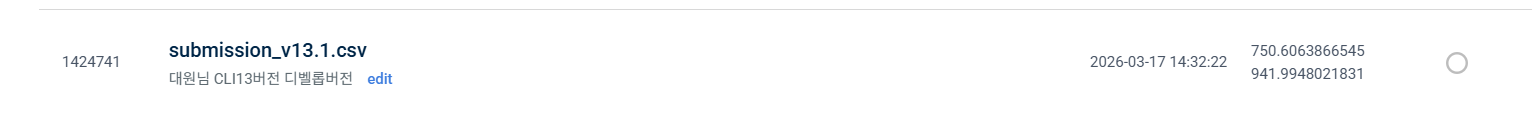